In [54]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(REPO_ROOT / "code"))
from make_network import * 
import numpy as np 
import pandas as pd 
import os 
import pickle
import matplotlib.pyplot as plt

from model_unified_ver import run_exp
from model_unified_ver import default_params as params
import utils as utl
from analysis_of_simulation_result import * 

syn_df = pd.read_parquet(REPO_ROOT/'data/Connectivity_783.parquet')

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

from adjustText import adjust_text
from scipy.stats import pearsonr

In [2]:
from scipy.stats import hmean

DATA_DIR = REPO_ROOT/'figure5/data'

def load_screening_result(filename, sheet_name):
    df = pd.read_excel(
        DATA_DIR / filename,
        sheet_name=sheet_name,
        header=1,
        index_col=0,
    )

    if "type" in df.index:
        df = df.drop(index="type")

    df.index.name = "type"
    return df

def calculate_network_characteristics(activation,silence,mode='sweet'):
    
    df_per_concent = {}
    for concent in silence.columns:
        if mode == 'sweet':
            slnc = silence[concent]
            act = activation[0]
            N = (slnc.loc['control'] - slnc)/slnc.loc['control']
            S = act - act.loc['control']
        else:
            slnc = silence[concent]
            act = activation[concent]
            N = (slnc - slnc.loc['control'])/slnc.loc['control']
            S = (act.loc['control'] - act)/act.loc['control']
        N = N.clip(lower=0)
        S = S.clip(lower=0)
        N, S = N.align(S)
        HM = hmean(np.vstack([N,S]))
        df = pd.DataFrame({
            'Necessity': N,
            'Sufficiency': S,
            'HM': HM
        }, index=N.index)    
        df[f'rank_v{concent}'] = df['HM'].rank(ascending=False, method='min').astype(int)
        df_per_concent[concent] = df 
    
    return df_per_concent 



### Sweet ###
# Tarsal
tarsal_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "tarsal",
)
tarsal_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "tarsal",
)


# Labellar
labial_activation_per = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation.xlsx",
    "labellar",
)
labial_activation_per_sem = load_screening_result(
    DATA_DIR/"Sweet_activation_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_activation_per = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation.xlsx",
    "labellar",
)
labial_geosmin_activation_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_activation_simulation_sem.xlsx",
    "labellar",
)



### Sweet ###
# Tarsal
tarsal_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_screening_per = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation.xlsx",
    "labellar",
)
labial_screening_per_sem = load_screening_result(
    DATA_DIR/"Sweet_Screening_simulation_sem.xlsx",
    "labellar",
)


### Geosmin ###
tarsal_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "tarsal",
)
tarsal_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "tarsal",
)

# Labellar
labial_geosmin_screening_per = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation.xlsx",
    "labellar",
)
labial_geosmin_screening_per_sem = load_screening_result(
    DATA_DIR/"Geosmin_Screening_simulation_sem.xlsx",
    "labellar",
)


tarsal_sweet_df = calculate_network_characteristics(tarsal_activation_per,tarsal_screening_per,mode='sweet')
labial_sweet_df = calculate_network_characteristics(labial_activation_per,labial_screening_per,mode='sweet')
tarsal_geosmin_df = calculate_network_characteristics(tarsal_geosmin_activation_per,tarsal_geosmin_screening_per,mode='geosmin')
labial_geosmin_df = calculate_network_characteristics(labial_geosmin_activation_per,labial_geosmin_screening_per,mode='geosmin')


In [ ]:
mean

In [74]:
np.mean([tarsal_sweet_df[x].loc['5304','Necessity'] for x in [10,50,100,500]])

0.3564270600064615

In [78]:
tarsal_sweet_df[100]

,Necessity,Sufficiency,HM,rank_v100
type,,,,
control,0.000000,0.000000,0.000000,51
7625,0.781035,0.674998,0.724155,1
1485,0.756392,0.639327,0.692950,2
5342,0.510692,0.124097,0.199673,14
7014,0.449438,0.427904,0.438407,5
5304,0.415649,0.672732,0.513828,3
535,0.334164,0.674827,0.446986,4
7272,0.315468,0.674697,0.429919,6
6103,0.301553,0.010917,0.021071,27


In [50]:
mean_data_necessity = {}
mean_data_necessity['tarsal'] = pd.concat([y['Necessity'] for x,y in tarsal_sweet_df.items()],axis=1).mean(axis=1).drop('control')
mean_data_necessity['labial'] = pd.concat([y['Necessity'] for x,y in labial_sweet_df.items()],axis=1).mean(axis=1).drop('control')

mean_data_sufficiency = {}
mean_data_sufficiency['tarsal'] = pd.concat([y['Sufficiency'] for x,y in tarsal_sweet_df.items()],axis=1).mean(axis=1).drop('control')
mean_data_sufficiency['labial'] = pd.concat([y['Sufficiency'] for x,y in labial_sweet_df.items()],axis=1).mean(axis=1).drop('control')


color_path = REPO_ROOT/'figure6/figure6C,F,L,O_Compare_necessity_exp_vs_simul/data'
color_info_all = {}
for g in ['tarsal','labial']:
    color_info_all[g] = pickle.load(open(os.path.join(color_path,f'color_info_{g}-union.pkl'),'rb'))

In [27]:
rank_df = pd.read_parquet(REPO_ROOT/'figure5/figure5Q,R/data/labial_geosmin_rank.parquet')
type_in_av1a1 = rank_df[np.any(rank_df<=20,axis=1)].index.values.astype(int)#rank_df.index.values.astype(int)#r
c_in_path = target_ids_valid_all[np.isin(g_info_all,type_in_av1a1)]

inhibitory_neurons_labial = [c for c in c_in_path if np.sum(syn_df[syn_df.Presynaptic_ID==c]['Excitatory']<0)>0]#cell_in_network_per_type['av1a1']
print(list(np.unique([fid2g[x] for x in inhibitory_neurons_labial]).astype(int)))
inhibitory_type_labial = list(np.unique([fid2g[x] for x in inhibitory_neurons_labial]).astype(int))


rank_df = pd.read_parquet(REPO_ROOT/'figure5/figure5Q,R/data/tarsal_geosmin_rank.parquet')
type_in_av1a1 = rank_df[np.any(rank_df<=20,axis=1)].index.values.astype(int) #rank_df.index.values.astype(int)#
c_in_path = target_ids_valid_all[np.isin(g_info_all,type_in_av1a1)]

inhibitory_neurons_tarsal = [c for c in c_in_path if np.sum(syn_df[syn_df.Presynaptic_ID==c]['Excitatory']<0)>0]#cell_in_network_per_type['av1a1']
print(list(np.unique([fid2g[x] for x in inhibitory_neurons_tarsal]).astype(int)))
inhibitory_type_tarsal = list(np.unique([fid2g[x] for x in inhibitory_neurons_tarsal]).astype(int))

[564, 3147, 4512, 4617, 5694, 6110, 6755, 6987, 7072, 7648, 7673, 9018]
[818, 1313, 3147, 4512, 4617, 6755, 7072, 7922, 8817]


In [28]:
in_tarsal = mean_data_necessity['tarsal'].index
in_labial = mean_data_necessity['labial'].index
only_tarsal = np.setdiff1d(in_tarsal,in_labial)
only_labial = np.setdiff1d(in_labial,in_tarsal)

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

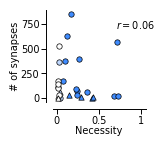

In [65]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

# necess_df_mean = pd.concat([criterion_df_tarsal[x]['necessity'] for x in [10,50,100,500]],axis=1).mean(axis=1)

ps = 15

fig,ax = plt.subplots(1,1,figsize=(1.2,1.2))

type_in_network = mean_data_necessity['tarsal'].index
cell_in_network = target_ids_valid_all[np.isin(g_info_all,type_in_network.astype(int))]
inhibitory_neurons = inhibitory_neurons_tarsal#np.union1d(inhibitory_neurons_labial,inhibitory_neurons_tarsal)
post_df = syn_df[np.isin(syn_df.Presynaptic_ID.values,inhibitory_neurons)&np.isin(syn_df.Postsynaptic_ID.values,cell_in_network)]
post_groups = np.array([fid2g[x] for x in post_df.Postsynaptic_ID.values])
inhibitory_conn_per_type = {}
for g in np.unique(post_groups):
    inhibitory_conn_per_type[str(int(g))] = -1*np.sum(post_df[post_groups==g]['Excitatory x Connectivity'].values)

# inhibitory_inputs_tarsal = list(inhibitory_conn_per_type.values())
# inhibitory_conn_per_type_tarsal = inhibitory_conn_per_type

X = []
Y = [] 
texts = []
for g in mean_data_necessity['tarsal'].index:
    if color_info_all['tarsal'][int(g)]!='#777777':
        if str(g) not in inhibitory_conn_per_type.keys():
                x = 0 
                y = mean_data_necessity['tarsal'].loc[g]
        else:
            x = inhibitory_conn_per_type[str(g)]
            y = mean_data_necessity['tarsal'].loc[g]
        if g in only_tarsal:
            ax.scatter(y,x,color=color_info_all['tarsal'][int(g)],s=ps,linewidths=.5,edgecolors='black',marker='^')
        else:
            ax.scatter(y,x,color=color_info_all['tarsal'][int(g)],s=ps,linewidths=.5,edgecolors='black')
        
    X.append(y)
    Y.append(x)

    label = g#necess_df_mean.loc[g,'canonical']
#     texts.append(ax.text(y, x, label, fontsize=7))

# adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', lw=0.3))

ax.spines[['top','right']].set_visible(False)
ax.set_ylabel('# of synapses',fontsize=7)
ax.set_xlabel('Necessity',fontsize=7)
# ax.set_ylabel(r'$1 - \frac{r_{\mathrm{MN9,\ silencing}}}{r_{\mathrm{MN9,\ ctrl}}}$',fontsize=10*1.5)
ax.set_xlim([-.05,1.05])
ax.set_yticks([0,250,500,750])
ax.set_xticks([0,.5,1],[0,.5,1])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)

R = pearsonr(X,Y)
ax.text(.7,700,f'$r = ${np.round(R.statistic,2)}')
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
plt.savefig('Num_inhibitory_syn_vs_Necessity_tarsal.svg')

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

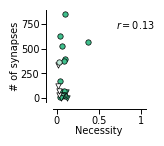

In [64]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['svg.fonttype'] = 'none'
matplotlib.rcParams['font.family'] = 'Arial'
matplotlib.rcParams['font.size'] = 7

# necess_df_mean = pd.concat([criterion_df_tarsal[x]['necessity'] for x in [10,50,100,500]],axis=1).mean(axis=1)

ps = 15

fig,ax = plt.subplots(1,1,figsize=(1.2,1.2))

type_in_network = mean_data_necessity['labial'].index.astype(int)
cell_in_network = target_ids_valid_all[np.isin(g_info_all,type_in_network)]
inhibitory_neurons = inhibitory_neurons_tarsal#np.union1d(inhibitory_neurons_labial,inhibitory_neurons_tarsal)
post_df = syn_df[np.isin(syn_df.Presynaptic_ID.values,inhibitory_neurons)&np.isin(syn_df.Postsynaptic_ID.values,cell_in_network)]
post_groups = np.array([fid2g[x] for x in post_df.Postsynaptic_ID.values])
inhibitory_conn_per_type = {}
for g in np.unique(post_groups):
    inhibitory_conn_per_type[str(int(g))] = -1*np.sum(post_df[post_groups==g]['Excitatory x Connectivity'].values)

inhibitory_inputs_tarsal = list(inhibitory_conn_per_type.values())
inhibitory_conn_per_type_tarsal = inhibitory_conn_per_type

X = []
Y = [] 
texts = []
for g in mean_data_necessity['labial'].index:
    if color_info_all['labial'][int(g)]!='#777777':
        if str(g) not in inhibitory_conn_per_type.keys():
                x = 0 
                y = mean_data_necessity['labial'].loc[g]
        else:
            x = inhibitory_conn_per_type[str(g)]
            y = mean_data_necessity['labial'].loc[g]
        if g in only_labial:
            ax.scatter(y,x,color=color_info_all['labial'][int(g)],s=ps,linewidths=.5,edgecolors='black',marker='v')
        else:
            ax.scatter(y,x,color=color_info_all['labial'][int(g)],s=ps,linewidths=.5,edgecolors='black')
    
    X.append(y)
    Y.append(x)

    label = g#necess_df_mean.loc[g,'canonical']
#     texts.append(ax.text(y, x, label, fontsize=7))

# adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle='-', lw=0.3))

ax.spines[['top','right']].set_visible(False)
ax.set_ylabel('# of synapses',fontsize=7)
ax.set_xlabel('Necessity',fontsize=7)
# ax.set_ylabel(r'$1 - \frac{r_{\mathrm{MN9,\ silencing}}}{r_{\mathrm{MN9,\ ctrl}}}$',fontsize=10*1.5)
ax.set_xlim([-.05,1.05])
ax.set_xticks([0,.5,1],[0,.5,1])
ax.set_yticks([0,250,500,750])
ax.spines['left'].set_position(('outward', 5))
ax.spines['bottom'].set_position(('outward', 5))
ax.xaxis.labelpad = 0.5
ax.yaxis.labelpad = 0.5
ax.tick_params(pad=1)

R = pearsonr(X,Y)
ax.text(.7,700,f'$r = ${np.round(R.statistic,2)}')
ax.tick_params(
    axis='both',
    width=0.7
)

# Axis (spine) thickness
for spine in ax.spines.values():
    spine.set_linewidth(0.7)
plt.savefig('Num_inhibitory_syn_vs_Necessity_labial.svg')

In [61]:
X

[0.3684036986324113,
 0.123405043435223,
 0.11117741312354903,
 0.09900419731823304,
 0.085344856268426,
 0.09514646777509143,
 0.09111733363481476,
 0.09593352565486254,
 0.08084256866522416,
 0.07662008115534802,
 0.06409987174631526,
 0.0621915725731291,
 0.0511011078843294,
 0.057223342908735965,
 0.04110112464971878,
 0.04399540887578888,
 0.04343325442226238,
 0.04478839526730815,
 0.04221894275527378,
 0.028074302635567542,
 0.020721940335066736,
 0.017399298502763703,
 0.017399298502763703,
 0.021875305888675308,
 0.021875305888675308,
 0.021875305888675308,
 0.021875305888675308,
 0.021875305888675308,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.02655182661648723,
 0.0265

In [1]:
mean_data_sufficiency

NameError: name 'mean_data_sufficiency' is not defined